# Notebook 14 -- Inference Pipeline & Test-Set Prediction

<div style="border-left: 4px solid #4680a7; padding: 10px 15px; margin: 10px 0; background: #4e6681;">

**Objective:** Load the finalized tuned model artifact bundle, validate feature schema parity against the integrated test feature matrix, produce deterministic batch predictions with threshold optimization, generate the submission file and detailed prediction Parquet, run fail-safe degradation tests, verify reproducibility, profile latency, and produce a structured inference audit log.

</div>

| Item | Detail |
|------|--------|
| **Dependencies** | `artifacts/models/tuned_v1/`, `data/features/integrated/v1/test.parquet`, `configs/inference/serving.yaml` |
| **Artifacts** | `data/submissions/submission_tuned_v1.csv`, `data/output/predictions_tuned_v1.parquet`, `reports/metrics/inference_audit_tuned_v1.json` |
| **Scope** | Batch inference, schema validation, prediction diagnostics, submission generation, production-readiness verification |
| **Runtime** | < 60 seconds |

## 1. Setup & Configuration

In [1]:
from __future__ import annotations

import json
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from adoption_accelerator import config
from adoption_accelerator.training.artifacts import load_model_bundle
from adoption_accelerator.training.evaluation import apply_thresholds
from adoption_accelerator.inference.data_loader import load_inference_data
from adoption_accelerator.inference.validator import (
    validate_model_bundle,
    validate_feature_schema_parity,
    validate_data_quality,
)
from adoption_accelerator.inference.predictor import (
    predict_probabilities,
    compute_expected_values,
)
from adoption_accelerator.inference.formatter import (
    CLASS_LABELS,
    format_predictions,
    generate_submission,
)
from adoption_accelerator.inference.diagnostics import (
    compute_prediction_diagnostics,
    run_degradation_test,
    verify_reproducibility,
    profile_inference_latency,
)
from adoption_accelerator.inference.audit import generate_audit_log
from adoption_accelerator.inference.visualization import (
    plot_prediction_distribution,
    plot_confidence_distribution,
)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
logger = logging.getLogger(__name__)

SEED = config.SEED
np.random.seed(SEED)

print(f"Project root : {config.PROJECT_ROOT}")
print(f"Seed         : {SEED}")

Project root : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator
Seed         : 42


## 2. Load Inference Configuration

In [2]:
inference_config_path = config.PROJECT_ROOT / "configs" / "inference" / "serving.yaml"
with open(inference_config_path, encoding="utf-8") as f:
    inf_cfg = yaml.safe_load(f)

# Resolve key configuration values
BUNDLE_PATH = config.PROJECT_ROOT / inf_cfg["model"]["bundle_path"]
FEATURE_VERSION = inf_cfg["feature_version"]
EXPECTED_TEST_ROWS = inf_cfg["expected"]["test_rows"]
EXPECTED_N_FEATURES = inf_cfg["expected"]["n_features"]
N_CLASSES = inf_cfg["target"]["n_classes"]
PREDICTION_METHOD = inf_cfg["prediction"]["method"]
LOW_CONF_THRESHOLD = inf_cfg["diagnostics"]["low_confidence_threshold"]
LATENCY_REPEATS = inf_cfg["diagnostics"]["latency_profiling_repeats"]

# Output paths
SUBMISSION_PATH = config.PROJECT_ROOT / inf_cfg["output"]["submission_path"]
PREDICTIONS_PATH = config.PROJECT_ROOT / inf_cfg["output"]["predictions_path"]
AUDIT_LOG_PATH = config.PROJECT_ROOT / inf_cfg["output"]["audit_log_path"]
FIGURES_DIR = config.REPORTS_FIGURES / "inference"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Ensure output directories exist
SUBMISSION_PATH.parent.mkdir(parents=True, exist_ok=True)
PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
AUDIT_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

# Accumulator for validation gate results
gate_results: dict[str, dict] = {}

print(f"Bundle path      : {BUNDLE_PATH}")
print(f"Feature version  : {FEATURE_VERSION}")
print(f"Expected rows    : {EXPECTED_TEST_ROWS}")
print(f"Expected features: {EXPECTED_N_FEATURES}")
print(f"Prediction method: {PREDICTION_METHOD}")
print(f"Submission output: {SUBMISSION_PATH}")
print(f"Predictions output: {PREDICTIONS_PATH}")
print(f"Audit log output : {AUDIT_LOG_PATH}")

Bundle path      : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\artifacts\models\tuned_v1
Feature version  : v1
Expected rows    : 3972
Expected features: 940
Prediction method: threshold
Submission output: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\data\submissions\submission_tuned_v1.csv
Predictions output: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\data\output\predictions_tuned_v1.parquet
Audit log output : C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\metrics\inference_audit_tuned_v1.json


## 3. Load Model Artifact Bundle

In [3]:
bundle = load_model_bundle(BUNDLE_PATH)

# Extract components
model = bundle["model"]
thresholds_obj = bundle["thresholds"]
model_config = bundle["config"]
model_metrics = bundle["metrics"]
feature_schema = bundle["feature_schema"]

threshold_values = thresholds_obj["thresholds"]

print(f"Model type       : {type(model).__name__}")
print(f"Thresholds       : {threshold_values}")
print(f"CV QWK (stored)  : {model_metrics.get('mean_qwk_threshold', 'N/A')}")
print(f"Feature schema   : {len(feature_schema.get('features', []))} features")
print(f"Bundle keys      : {list(bundle.keys())}")

INFO | adoption_accelerator.training.artifacts | Model bundle loaded from C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\artifacts\models\tuned_v1


Model type       : SoftVotingEnsemble
Thresholds       : [0.35980548537511614, 2.1803755879779203, 2.4880468100053186, 2.953441885974602]
CV QWK (stored)  : 0.4932657788432109
Feature schema   : 940 features
Bundle keys      : ['model', 'metrics', 'config', 'thresholds', 'feature_schema']


## 4. Validate Model Artifact Integrity

Gates `G14-1` (bundle completeness), `G14-2` (CV QWK match), `G14-8` (thresholds valid).

In [4]:
bundle_report = validate_model_bundle(
    bundle,
    expected_n_features=EXPECTED_N_FEATURES,
    expected_cv_qwk=inf_cfg["model"]["expected_cv_qwk"],
    qwk_tolerance=1e-2,
)

# Merge gates into the accumulator
gate_results.update(bundle_report["gates"])

assert bundle_report["passed"], (
    f"Model bundle validation FAILED: {bundle_report['gates']}"
)

for gate_id, result in bundle_report["gates"].items():
    print(f"  [{gate_id}] {result['status']} -- {result['detail']}")

INFO | adoption_accelerator.inference.validator | [G14-1] PASS -- All components present
INFO | adoption_accelerator.inference.validator | [G14-1b] PASS -- Feature schema defines 940 features (expected 940)
INFO | adoption_accelerator.inference.validator | [G14-2] PASS -- CV QWK = 0.493266 (expected ~0.4933, diff=0.000034)
INFO | adoption_accelerator.inference.validator | [G14-8] PASS -- Thresholds count: 4 (expected 4)
INFO | adoption_accelerator.inference.validator | [G14-8b] PASS -- Thresholds ascending: True -- [0.35980548537511614, 2.1803755879779203, 2.4880468100053186, 2.953441885974602]


  [G14-1] PASS -- All components present
  [G14-1b] PASS -- Feature schema defines 940 features (expected 940)
  [G14-2] PASS -- CV QWK = 0.493266 (expected ~0.4933, diff=0.000034)
  [G14-8] PASS -- Thresholds count: 4 (expected 4)
  [G14-8b] PASS -- Thresholds ascending: True -- [0.35980548537511614, 2.1803755879779203, 2.4880468100053186, 2.953441885974602]


## 5. Load Test Feature Matrix

Gates `G14-3` (row/feature counts), `G14-4` (no target column).

In [5]:
X_test, _, pet_ids = load_inference_data(
    feature_version=FEATURE_VERSION, split="test"
)

# G14-3: Row and feature counts
assert X_test.shape[0] == EXPECTED_TEST_ROWS, (
    f"G14-3 FAIL: Expected {EXPECTED_TEST_ROWS} rows, got {X_test.shape[0]}"
)
assert X_test.shape[1] == EXPECTED_N_FEATURES, (
    f"G14-3 FAIL: Expected {EXPECTED_N_FEATURES} features, got {X_test.shape[1]}"
)
gate_results["G14-3"] = {
    "status": "PASS",
    "detail": f"Test matrix: {X_test.shape[0]} rows x {X_test.shape[1]} features",
}

# G14-4: No target column
assert "AdoptionSpeed" not in X_test.columns, "G14-4 FAIL: AdoptionSpeed found in test set"
gate_results["G14-4"] = {
    "status": "PASS",
    "detail": "No AdoptionSpeed column in test feature matrix",
}

print(f"[G14-3] PASS -- Test matrix: {X_test.shape[0]} rows x {X_test.shape[1]} features")
print(f"[G14-4] PASS -- No AdoptionSpeed column in test feature matrix")
print(f"PetIDs sample: {pet_ids[:5].tolist()}")
X_test.head(3)

INFO | adoption_accelerator.inference.data_loader | Loading test features from C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\data\features\integrated\v1\test.parquet
INFO | adoption_accelerator.inference.data_loader | Loaded test split: 3972 rows x 940 features


[G14-3] PASS -- Test matrix: 3972 rows x 940 features
[G14-4] PASS -- No AdoptionSpeed column in test feature matrix
PetIDs sample: ['e2dfc2935', 'f153b465f', '3c90f3f54', 'e02abc8a3', '09f0df7d1']


,is_dog,Gender,MaturitySize,FurLength,Health,Vaccinated,Dewormed,Sterilized,health_care_score,Age,...,img_emb_99,mean_image_brightness,mean_blur_score,image_size_std,meta_label_count_mean,meta_top_label_score_mean,meta_dominant_color_count_mean,meta_avg_brightness_mean,meta_color_diversity_mean,meta_crop_confidence_mean
PetID,,,,,,,,,,,,,,,,,,,,,
e2dfc2935,0,1,1,1,1,1,1,0,2,8,...,-0.244194,134.22,530.44,0.00,10.0,0.9946,10.0,79.665001,51.575001,0.80
f153b465f,0,2,2,3,2,1,1,1,3,36,...,0.208329,113.45,670.38,0.00,10.0,0.9945,10.0,92.669998,48.540001,0.80
3c90f3f54,0,1,2,2,1,1,1,0,2,2,...,0.287220,95.82,457.29,68379.68,10.0,0.9920,10.0,137.649994,48.062500,0.85


## 6. Feature Schema Parity Validation

Gate `G14-5`: Column names, order, and count must match the model bundle `feature_schema.json` exactly.

In [6]:
parity_report = validate_feature_schema_parity(X_test, feature_schema)

assert parity_report["passed"], (
    f"G14-5 FAIL: Feature schema parity failed -- {parity_report['details']}"
)
gate_results["G14-5"] = {
    "status": "PASS",
    "detail": (
        f"Column count match: {parity_report['details']['column_count']['match']}, "
        f"order match: {parity_report['details']['order_match']}, "
        f"missing: {len(parity_report['details']['missing_columns'])}, "
        f"extra: {len(parity_report['details']['extra_columns'])}"
    ),
}

print(f"[G14-5] PASS -- Feature schema parity validated")
print(f"  Columns: {parity_report['details']['column_count']}")
print(f"  Order match: {parity_report['details']['order_match']}")
print(f"  Missing: {parity_report['details']['missing_columns']}")
print(f"  Extra  : {parity_report['details']['extra_columns']}")

INFO | adoption_accelerator.inference.validator | Feature schema parity: PASS (940 columns match)


[G14-5] PASS -- Feature schema parity validated
  Columns: {'expected': 940, 'actual': 940, 'match': True}
  Order match: True
  Missing: []
  Extra  : []


## 7. Data Quality Validation

Gates `G14-6` (no NaN), `G14-7` (no infinite values).

In [7]:
quality_report = validate_data_quality(X_test)

# G14-6: No NaN
nan_count = quality_report["details"]["nan_count"]
assert nan_count == 0, f"G14-6 FAIL: {nan_count} NaN values found"
gate_results["G14-6"] = {
    "status": "PASS",
    "detail": f"0 NaN values in {X_test.shape[1]} columns",
}

# G14-7: No infinite values
inf_count = quality_report["details"]["inf_count"]
assert inf_count == 0, f"G14-7 FAIL: {inf_count} Inf values found"
gate_results["G14-7"] = {
    "status": "PASS",
    "detail": f"0 Inf values in {X_test.shape[1]} columns",
}

print(f"[G14-6] PASS -- 0 NaN values")
print(f"[G14-7] PASS -- 0 Inf values")
print(f"Data quality: PASS")

INFO | adoption_accelerator.inference.validator | Data quality: PASS (0 NaN, 0 Inf, 940 columns)


[G14-6] PASS -- 0 NaN values
[G14-7] PASS -- 0 Inf values
Data quality: PASS


## 8. Predict Class Probabilities

Gates `G14-9` (shape), `G14-10` (range [0,1]), `G14-11` (rows sum to 1.0).

In [8]:
probabilities = predict_probabilities(model, X_test, n_classes=N_CLASSES)

# G14-9: Shape check
assert probabilities.shape == (EXPECTED_TEST_ROWS, N_CLASSES), (
    f"G14-9 FAIL: Shape {probabilities.shape} != ({EXPECTED_TEST_ROWS}, {N_CLASSES})"
)
gate_results["G14-9"] = {
    "status": "PASS",
    "detail": f"Probability shape: {probabilities.shape}",
}

# G14-10: Range [0, 1]
assert np.all(probabilities >= 0) and np.all(probabilities <= 1), "G14-10 FAIL"
gate_results["G14-10"] = {
    "status": "PASS",
    "detail": f"All probabilities in [0, 1] -- range [{probabilities.min():.6f}, {probabilities.max():.6f}]",
}

# G14-11: Row sums
row_sums = probabilities.sum(axis=1)
max_dev = float(np.max(np.abs(row_sums - 1.0)))
assert max_dev < 1e-6, f"G14-11 FAIL: Max row-sum deviation = {max_dev:.2e}"
gate_results["G14-11"] = {
    "status": "PASS",
    "detail": f"Max row-sum deviation from 1.0: {max_dev:.2e}",
}

print(f"[G14-9]  PASS -- Probability shape: {probabilities.shape}")
print(f"[G14-10] PASS -- Range: [{probabilities.min():.6f}, {probabilities.max():.6f}]")
print(f"[G14-11] PASS -- Max row-sum deviation: {max_dev:.2e}")
print(f"\nSample probabilities (first 3 rows):")
print(pd.DataFrame(probabilities[:3], columns=[f"P(class={i})" for i in range(N_CLASSES)]))

INFO | adoption_accelerator.inference.predictor | Predicted probabilities: shape=(3972, 5), range=[0.0011, 0.9132]


[G14-9]  PASS -- Probability shape: (3972, 5)
[G14-10] PASS -- Range: [0.001139, 0.913169]
[G14-11] PASS -- Max row-sum deviation: 2.67e-08

Sample probabilities (first 3 rows):
   P(class=0)  P(class=1)  P(class=2)  P(class=3)  P(class=4)
0    0.020775    0.177022    0.272975    0.216543    0.312685
1    0.035828    0.286772    0.252033    0.252835    0.172532
2    0.022307    0.294413    0.485801    0.130599    0.066879


## 9. Compute Expected Values

Gate `G14-12`: All expected values must be in [0.0, 4.0].

In [9]:
expected_values = compute_expected_values(probabilities)

# G14-12: Range check
assert np.all(expected_values >= 0.0) and np.all(expected_values <= 4.0), (
    f"G14-12 FAIL: EV range [{expected_values.min():.4f}, {expected_values.max():.4f}]"
)
gate_results["G14-12"] = {
    "status": "PASS",
    "detail": f"Expected values in [0, 4] -- range [{expected_values.min():.4f}, {expected_values.max():.4f}]",
}

print(f"[G14-12] PASS -- EV range: [{expected_values.min():.4f}, {expected_values.max():.4f}]")
print(f"EV mean: {expected_values.mean():.4f}, std: {expected_values.std():.4f}")

INFO | adoption_accelerator.inference.predictor | Expected values: mean=2.5282, std=0.4935, range=[1.4439, 3.8544]


[G14-12] PASS -- EV range: [1.4439, 3.8544]
EV mean: 2.5282, std: 0.4935


## 10. Apply Threshold Optimization

Gates `G14-13` (predictions in {0,...,4}), `G14-14` (no NaN predictions). Uses stored thresholds from training -- NO re-optimization on test data.

In [10]:
# apply_thresholds expects the full probability matrix, not expected values
predicted_classes = apply_thresholds(probabilities, threshold_values, n_classes=N_CLASSES)

# G14-13: All predictions in {0, 1, 2, 3, 4}
valid_classes = {0, 1, 2, 3, 4}
actual_classes = set(np.unique(predicted_classes))
assert actual_classes.issubset(valid_classes), (
    f"G14-13 FAIL: Invalid classes {actual_classes - valid_classes}"
)
gate_results["G14-13"] = {
    "status": "PASS",
    "detail": f"All predictions in {{0, 1, 2, 3, 4}} -- unique: {sorted(actual_classes)}",
}

# G14-14: No NaN predictions
assert not np.any(np.isnan(predicted_classes.astype(float))), "G14-14 FAIL: NaN predictions"
gate_results["G14-14"] = {
    "status": "PASS",
    "detail": "0 NaN predictions",
}

print(f"Thresholds applied: {threshold_values}")
print(f"[G14-13] PASS -- Unique classes: {sorted(actual_classes)}")
print(f"[G14-14] PASS -- 0 NaN predictions")
print(f"\nPrediction distribution:")
unique, counts = np.unique(predicted_classes, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt:>5d} ({cnt / len(predicted_classes) * 100:.1f}%)")

Thresholds applied: [0.35980548537511614, 2.1803755879779203, 2.4880468100053186, 2.953441885974602]
[G14-13] PASS -- Unique classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
[G14-14] PASS -- 0 NaN predictions

Prediction distribution:
  Class 1:  1097 (27.6%)
  Class 2:   953 (24.0%)
  Class 3:  1079 (27.2%)
  Class 4:   843 (21.2%)


## 11. Argmax Comparison

Compare threshold-optimized predictions against simple argmax predictions to quantify their disagreement rate.

In [11]:
argmax_classes = np.argmax(probabilities, axis=1)

disagreement_mask = argmax_classes != predicted_classes
disagreement_count = int(disagreement_mask.sum())
disagreement_pct = disagreement_count / len(predicted_classes) * 100

print(f"Threshold vs. Argmax comparison:")
print(f"  Disagreement: {disagreement_count}/{len(predicted_classes)} ({disagreement_pct:.1f}%)")
print(f"\nArgmax distribution:")
argmax_unique, argmax_counts = np.unique(argmax_classes, return_counts=True)
for cls, cnt in zip(argmax_unique, argmax_counts):
    print(f"  Class {cls}: {cnt:>5d} ({cnt / len(argmax_classes) * 100:.1f}%)")

# Cross-tabulation
ct = pd.crosstab(
    pd.Series(predicted_classes, name="Threshold"),
    pd.Series(argmax_classes, name="Argmax"),
)
print(f"\nCross-tabulation (Threshold rows x Argmax columns):")
ct

Threshold vs. Argmax comparison:
  Disagreement: 1639/3972 (41.3%)

Argmax distribution:
  Class 1:   901 (22.7%)
  Class 2:  1178 (29.7%)
  Class 3:   240 (6.0%)
  Class 4:  1653 (41.6%)

Cross-tabulation (Threshold rows x Argmax columns):


Argmax,1,2,3,4
Threshold,,,,
1,740,348,9,0
2,161,625,98,69
3,0,205,129,745
4,0,0,4,839


## 12. Prediction Distribution Analysis

Gate `G14-20` (warning): No class with 0 predictions. Compare predicted test distribution against training target distribution.

INFO | adoption_accelerator.inference.data_loader | Loading train features from C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\data\features\integrated\v1\train.parquet
INFO | adoption_accelerator.inference.data_loader | Loaded train split: 14993 rows x 940 features
INFO | adoption_accelerator.inference.visualization | Prediction distribution figure saved to C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\figures\inference\prediction_distribution.png


[G14-20] WARN -- Empty classes: [0]

Prediction distribution:
  Class 0 (Same-day adoption):     0 (0.0%)
  Class 1 (Adopted within 1 week):  1097 (27.6%)
  Class 2 (Adopted within 1 month):   953 (24.0%)
  Class 3 (Adopted within 1-3 months):  1079 (27.2%)
  Class 4 (Not adopted (100+ days)):   843 (21.2%)


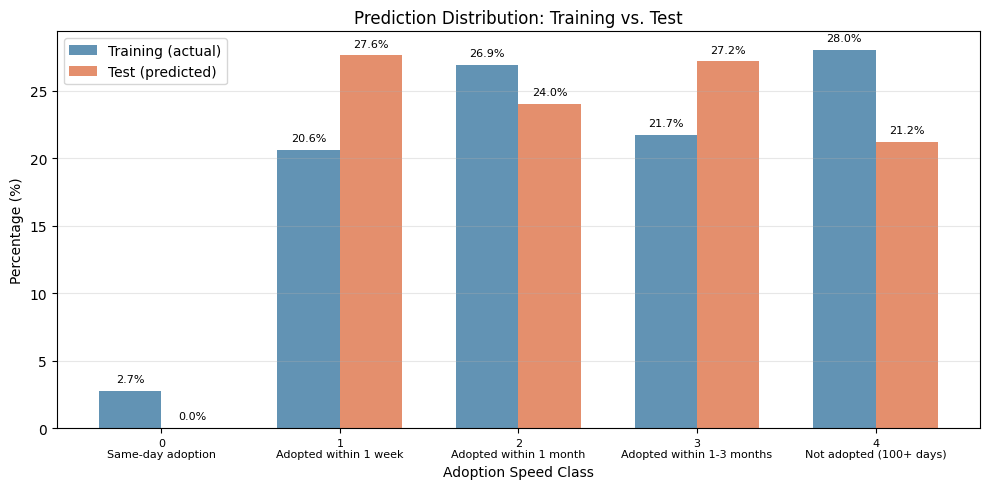

In [12]:
# Load training target distribution for comparison
_, y_train, _ = load_inference_data(feature_version=FEATURE_VERSION, split="train")
train_dist = dict(y_train.value_counts().sort_index())

diagnostics_report = compute_prediction_diagnostics(
    predicted_classes=predicted_classes,
    probabilities=probabilities,
    training_distribution=train_dist,
    low_confidence_threshold=LOW_CONF_THRESHOLD,
)

# G14-20: No class with 0 predictions (warning)
empty_classes = diagnostics_report["warnings"]["empty_classes"]
g20_status = "PASS" if len(empty_classes) == 0 else "WARN"
gate_results["G14-20"] = {
    "status": g20_status,
    "detail": f"Empty classes: {empty_classes}" if empty_classes else "All 5 classes represented",
}

print(f"[G14-20] {g20_status} -- {'All 5 classes represented' if not empty_classes else f'Empty classes: {empty_classes}'}")
print(f"\nPrediction distribution:")
for cls in range(N_CLASSES):
    n = diagnostics_report["prediction_distribution"].get(cls, 0)
    pct = diagnostics_report["prediction_distribution_pct"].get(cls, 0)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {n:>5d} ({pct:.1f}%)")

# Visualize -- save as both prediction_distribution and train_test_distribution_comparison
fig = plot_prediction_distribution(
    predicted_classes=predicted_classes,
    training_distribution=train_dist,
    save_path=FIGURES_DIR / "prediction_distribution.png",
    class_labels=CLASS_LABELS,
)
fig.savefig(
    FIGURES_DIR / "train_test_distribution_comparison.png",
    dpi=150, bbox_inches="tight",
)
plt.show()
plt.close(fig)

## 13. Confidence Analysis

Gate `G14-21` (warning): Mean confidence > 0.25 (above random baseline for 5 classes).

INFO | adoption_accelerator.inference.visualization | Confidence distribution figure saved to C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\figures\inference\confidence_distribution.png


[G14-21] PASS -- Mean confidence: 0.4173

Confidence statistics:
  Mean   : 0.4173
  Median : 0.3806
  Std    : 0.1197
  Min    : 0.2480
  Max    : 0.9132

Low-confidence predictions (< 0.3):
  Count  : 346
  Percent: 8.7%


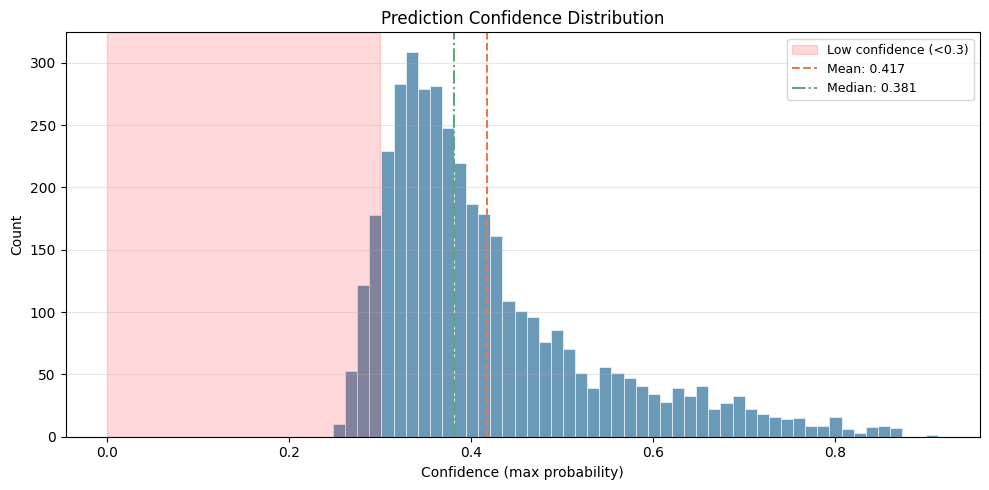

In [13]:
confidence = probabilities.max(axis=1)
conf_stats = diagnostics_report["confidence"]

# G14-21: Mean confidence > 0.25
g21_status = "PASS" if conf_stats["mean"] > 0.25 else "WARN"
gate_results["G14-21"] = {
    "status": g21_status,
    "detail": f"Mean confidence: {conf_stats['mean']:.4f} (threshold: 0.25)",
}

print(f"[G14-21] {g21_status} -- Mean confidence: {conf_stats['mean']:.4f}")
print(f"\nConfidence statistics:")
print(f"  Mean   : {conf_stats['mean']:.4f}")
print(f"  Median : {conf_stats['median']:.4f}")
print(f"  Std    : {conf_stats['std']:.4f}")
print(f"  Min    : {conf_stats['min']:.4f}")
print(f"  Max    : {conf_stats['max']:.4f}")
print(f"\nLow-confidence predictions (< {LOW_CONF_THRESHOLD}):")
print(f"  Count  : {diagnostics_report['low_confidence_count']}")
print(f"  Percent: {diagnostics_report['low_confidence_pct']:.1f}%")

# Visualize
fig = plot_confidence_distribution(
    confidences=confidence,
    save_path=FIGURES_DIR / "confidence_distribution.png",
    low_confidence_threshold=LOW_CONF_THRESHOLD,
)
plt.show()
plt.close(fig)

## 14. Generate Submission File

Gates `G14-15` (row/column count), `G14-16` (PetID uniqueness), `G14-17` (value domain).

In [14]:
submission_path = generate_submission(
    pet_ids=pet_ids,
    predicted_classes=predicted_classes,
    output_path=SUBMISSION_PATH,
)

# Validate the saved file
submission_df = pd.read_csv(submission_path)

# G14-15: Row and column count
assert submission_df.shape == (EXPECTED_TEST_ROWS, 2), (
    f"G14-15 FAIL: Shape {submission_df.shape}"
)
assert list(submission_df.columns) == ["PetID", "AdoptionSpeed"], (
    f"G14-15 FAIL: Columns {list(submission_df.columns)}"
)
gate_results["G14-15"] = {
    "status": "PASS",
    "detail": f"Submission: {submission_df.shape[0]} rows, {submission_df.shape[1]} columns",
}

# G14-16: PetID uniqueness and match
assert not submission_df["PetID"].duplicated().any(), "G14-16 FAIL: Duplicate PetIDs"
assert set(submission_df["PetID"]) == set(pet_ids), "G14-16 FAIL: PetID mismatch"
gate_results["G14-16"] = {
    "status": "PASS",
    "detail": f"All {len(pet_ids)} PetIDs unique and matching",
}

# G14-17: Value domain
assert set(submission_df["AdoptionSpeed"].unique()).issubset({0, 1, 2, 3, 4}), "G14-17 FAIL"
gate_results["G14-17"] = {
    "status": "PASS",
    "detail": f"All values in {{0, 1, 2, 3, 4}}",
}

print(f"[G14-15] PASS -- Submission: {submission_df.shape[0]} rows x {submission_df.shape[1]} columns")
print(f"[G14-16] PASS -- All PetIDs unique and matching")
print(f"[G14-17] PASS -- All AdoptionSpeed values in {{0,1,2,3,4}}")
print(f"\nSubmission saved to: {submission_path}")
submission_df.head()

INFO | adoption_accelerator.inference.formatter | Submission saved: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\data\submissions\submission_tuned_v1.csv (3972 rows, 2 columns)


[G14-15] PASS -- Submission: 3972 rows x 2 columns
[G14-16] PASS -- All PetIDs unique and matching
[G14-17] PASS -- All AdoptionSpeed values in {0,1,2,3,4}

Submission saved to: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\data\submissions\submission_tuned_v1.csv


,PetID,AdoptionSpeed
0,e2dfc2935,3
1,f153b465f,2
2,3c90f3f54,1
3,e02abc8a3,4
4,09f0df7d1,4


## 15. Generate Prediction Detail File

Gate `G14-24`: Prediction detail Parquet saved with correct schema.

In [15]:
predictions_df = format_predictions(
    pet_ids=pet_ids,
    predicted_classes=predicted_classes,
    probabilities=probabilities,
    expected_values=expected_values,
    argmax_classes=argmax_classes,
)

# Save predictions Parquet
PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
predictions_df.to_parquet(PREDICTIONS_PATH)

# G14-24: Validate saved schema
saved_df = pd.read_parquet(PREDICTIONS_PATH)
expected_cols = [
    "predicted_class", "predicted_label", "confidence", "expected_value",
    "prob_class_0", "prob_class_1", "prob_class_2", "prob_class_3", "prob_class_4",
    "argmax_class", "prediction_method",
]
assert list(saved_df.columns) == expected_cols, (
    f"G14-24 FAIL: Column mismatch -- got {list(saved_df.columns)}"
)
assert saved_df.shape[0] == EXPECTED_TEST_ROWS, (
    f"G14-24 FAIL: Row count {saved_df.shape[0]} != {EXPECTED_TEST_ROWS}"
)
gate_results["G14-24"] = {
    "status": "PASS",
    "detail": f"Predictions Parquet: {saved_df.shape[0]} rows, {saved_df.shape[1]} columns, schema correct",
}

print(f"[G14-24] PASS -- Predictions Parquet saved: {PREDICTIONS_PATH}")
print(f"  Shape: {saved_df.shape}")
print(f"  Columns: {list(saved_df.columns)}")
predictions_df.head()

INFO | adoption_accelerator.inference.formatter | Formatted prediction detail: 3972 rows, 11 columns


[G14-24] PASS -- Predictions Parquet saved: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\data\output\predictions_tuned_v1.parquet
  Shape: (3972, 11)
  Columns: ['predicted_class', 'predicted_label', 'confidence', 'expected_value', 'prob_class_0', 'prob_class_1', 'prob_class_2', 'prob_class_3', 'prob_class_4', 'argmax_class', 'prediction_method']


,predicted_class,predicted_label,confidence,expected_value,prob_class_0,prob_class_1,prob_class_2,prob_class_3,prob_class_4,argmax_class,prediction_method
PetID,,,,,,,,,,,
e2dfc2935,3,Adopted within 1-3 months,0.312685,2.623342,0.020775,0.177022,0.272975,0.216543,0.312685,4,threshold
f153b465f,2,Adopted within 1 month,0.286772,2.239470,0.035828,0.286772,0.252033,0.252835,0.172532,1,threshold
3c90f3f54,1,Adopted within 1 week,0.485801,1.925330,0.022307,0.294413,0.485801,0.130599,0.066879,2,threshold
e02abc8a3,4,Not adopted (100+ days),0.729922,3.564686,0.004378,0.023289,0.105524,0.136888,0.729922,4,threshold
09f0df7d1,4,Not adopted (100+ days),0.493094,3.042114,0.014392,0.072463,0.262879,0.157173,0.493094,4,threshold


## 16. Fail-Safe Degradation Test

Gate `G14-22` (warning): Pipeline does not crash on degraded input with zeroed-out image features.

In [16]:
# Identify modality columns from the integrated schema
from adoption_accelerator.inference.data_loader import load_feature_schema

int_schema = load_feature_schema(FEATURE_VERSION)
columns_meta = int_schema.get("columns", [])

# Build modality -> column list mapping
modality_columns: dict[str, list[str]] = {}
for col_info in columns_meta:
    source = col_info.get("source", "unknown")
    name = col_info["name"]
    if name == "AdoptionSpeed":
        continue
    modality_columns.setdefault(source, []).append(name)

print("Modality column counts:")
for mod, cols in modality_columns.items():
    print(f"  {mod}: {len(cols)} columns")

# Run degradation test (image modality zeroed)
degradation_results = run_degradation_test(
    model=model,
    X=X_test,
    feature_schema=feature_schema,
    modality_columns={"image": modality_columns.get("image", [])},
    thresholds=threshold_values,
    original_predictions=predicted_classes,
    n_classes=N_CLASSES,
)

# G14-22: Degradation test completes without exceptions
g22_completed = all(
    r.get("completed", False) for r in degradation_results.values()
    if not r.get("skipped", False)
)
g22_status = "PASS" if g22_completed else "WARN"
gate_results["G14-22"] = {
    "status": g22_status,
    "detail": str(degradation_results),
}

print(f"\n[G14-22] {g22_status} -- Degradation test results:")
for modality, result in degradation_results.items():
    if result.get("completed"):
        print(f"  {modality}: {result['prediction_change_pct']:.1f}% changed, mean shift={result['mean_class_shift']:.4f}")
    elif result.get("skipped"):
        print(f"  {modality}: SKIPPED ({result['reason']})")
    else:
        print(f"  {modality}: FAILED ({result.get('error', 'unknown')})")

Modality column counts:
  tabular: 45 columns
  text: 784 columns
  image: 111 columns


INFO | adoption_accelerator.inference.predictor | Predicted probabilities: shape=(3972, 5), range=[0.0043, 0.8762]
INFO | adoption_accelerator.inference.diagnostics | Degradation [image]: zeroed 111 cols, 55.9% preds changed, mean shift=0.6891



[G14-22] PASS -- Degradation test results:
  image: 55.9% changed, mean shift=0.6891


## 17. Reproducibility Verification

Gate `G14-18` (critical): Re-run must produce bit-identical predictions.

In [17]:
repro_result = verify_reproducibility(
    model=model,
    X=X_test,
    thresholds=threshold_values,
    first_predictions=predicted_classes,
    n_classes=N_CLASSES,
)

assert repro_result["passed"], f"G14-18 FAIL: {repro_result['detail']}"
gate_results["G14-18"] = {
    "status": "PASS",
    "detail": repro_result["detail"],
}

print(f"[G14-18] PASS -- {repro_result['detail']}")

INFO | adoption_accelerator.inference.predictor | Predicted probabilities: shape=(3972, 5), range=[0.0011, 0.9132]
INFO | adoption_accelerator.inference.diagnostics | Reproducibility test: PASS -- Bit-identical


[G14-18] PASS -- Bit-identical


## 18. Latency Profiling

Gate `G14-19` (warning): Per-sample inference latency < 100ms (prediction step only).

In [18]:
latency_profile = profile_inference_latency(
    model=model,
    X=X_test,
    thresholds=threshold_values,
    n_repeats=LATENCY_REPEATS,
    n_classes=N_CLASSES,
)

# G14-19: Per-sample latency < 100ms
per_sample_ms = latency_profile["per_sample_ms"]
g19_status = "PASS" if per_sample_ms < 100.0 else "WARN"
gate_results["G14-19"] = {
    "status": g19_status,
    "detail": f"Per-sample latency: {per_sample_ms:.4f}ms (target: <100ms)",
}

print(f"[G14-19] {g19_status} -- Per-sample latency: {per_sample_ms:.4f}ms")
print(f"\nLatency profile ({latency_profile['n_repeats']} repeats, {latency_profile['n_samples']} samples):")
print(f"  Total batch  : {latency_profile['total_batch_seconds']:.4f}s")
print(f"  Per-sample   : {latency_profile['per_sample_ms']:.4f}ms")
print(f"  Throughput   : {latency_profile['throughput_samples_per_second']:.0f} samples/s")
print(f"\nBreakdown:")
for step, ms in latency_profile["breakdown"].items():
    print(f"  {step}: {ms:.4f}ms")

INFO | adoption_accelerator.inference.predictor | Expected values: mean=2.5282, std=0.4935, range=[1.4439, 3.8544]
INFO | adoption_accelerator.inference.predictor | Expected values: mean=2.5282, std=0.4935, range=[1.4439, 3.8544]
INFO | adoption_accelerator.inference.predictor | Expected values: mean=2.5282, std=0.4935, range=[1.4439, 3.8544]
INFO | adoption_accelerator.inference.diagnostics | Latency profile: total=0.174s, per-sample=0.0437ms, throughput=22876 samples/s


[G14-19] PASS -- Per-sample latency: 0.0437ms

Latency profile (3 repeats, 3972 samples):
  Total batch  : 0.1736s
  Per-sample   : 0.0437ms
  Throughput   : 22876 samples/s

Breakdown:
  predict_proba_ms: 172.3806ms
  expected_value_ms: 1.0466ms
  threshold_application_ms: 0.2063ms


## 19. Generate Inference Audit Log

Gate `G14-23` (critical): Audit log persisted as valid JSON.

In [19]:
# Enrich diagnostics with reproducibility and degradation results
diagnostics_report["reproducibility_test"] = "PASS" if repro_result["passed"] else "FAIL"
diagnostics_report["degradation_test"] = degradation_results

audit_path = generate_audit_log(
    model_bundle=bundle,
    feature_version=FEATURE_VERSION,
    predictions=predicted_classes,
    probabilities=probabilities,
    diagnostics=diagnostics_report,
    latency_profile=latency_profile,
    config_snapshot=inf_cfg,
    validation_results=gate_results,
    submission_path=SUBMISSION_PATH,
    predictions_path=PREDICTIONS_PATH,
    output_path=AUDIT_LOG_PATH,
)

# G14-23: Validate audit log is valid JSON
with open(audit_path, encoding="utf-8") as f:
    audit_data = json.load(f)
assert isinstance(audit_data, dict), "G14-23 FAIL: Audit log is not a dict"
assert "run_id" in audit_data, "G14-23 FAIL: Missing run_id"
gate_results["G14-23"] = {
    "status": "PASS",
    "detail": f"Audit log saved: {audit_path} ({len(json.dumps(audit_data))} bytes)",
}

print(f"[G14-23] PASS -- Audit log saved to: {audit_path}")
print(f"  Run ID: {audit_data['run_id']}")
print(f"  Timestamp: {audit_data['timestamp']}")
print(f"  Keys: {list(audit_data.keys())}")

INFO | adoption_accelerator.inference.audit | Inference audit log saved to C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\metrics\inference_audit_tuned_v1.json


[G14-23] PASS -- Audit log saved to: C:\Projects\Personal_Projects\AI_Adoption_Acceleration\adoption_accelerator\reports\metrics\inference_audit_tuned_v1.json
  Run ID: inference_20260304_234106
  Timestamp: 2026-03-04T23:41:06.019397+00:00
  Keys: ['run_id', 'timestamp', 'model', 'data', 'predictions', 'validation_gates', 'diagnostics', 'latency', 'output_files', 'config_snapshot', 'environment']


## 20. Validation Gate Summary

Aggregate all 24 validation gates and assert overall pipeline integrity.

In [20]:
# Build gate summary table
gate_rows = []
for gate_id in sorted(gate_results.keys(), key=lambda g: (g.split("-")[0], g.split("-")[1] if "-" in g else "")):
    info = gate_results[gate_id]
    gate_rows.append({
        "Gate": gate_id,
        "Status": info["status"],
        "Detail": info["detail"],
    })

gate_df = pd.DataFrame(gate_rows)

# Count statuses
n_pass = (gate_df["Status"] == "PASS").sum()
n_warn = (gate_df["Status"] == "WARN").sum()
n_fail = (gate_df["Status"] == "FAIL").sum()

print("=" * 70)
print("VALIDATION GATE SUMMARY")
print("=" * 70)
print(f"  PASS: {n_pass}  |  WARN: {n_warn}  |  FAIL: {n_fail}")
print("=" * 70)

# All critical gates must pass
critical_gates = [
    "G14-1", "G14-2", "G14-3", "G14-4", "G14-5",
    "G14-6", "G14-7", "G14-8", "G14-9", "G14-10",
    "G14-11", "G14-12", "G14-13", "G14-14", "G14-15",
    "G14-16", "G14-17", "G14-18", "G14-23", "G14-24",
]
failed_critical = [
    g for g in critical_gates
    if gate_results.get(g, {}).get("status") == "FAIL"
]
assert len(failed_critical) == 0, (
    f"CRITICAL GATES FAILED: {failed_critical}"
)
print("\nAll critical gates PASSED.")

gate_df

VALIDATION GATE SUMMARY
  PASS: 25  |  WARN: 1  |  FAIL: 0

All critical gates PASSED.


,Gate,Status,Detail
0,G14-1,PASS,All components present
1,G14-10,PASS,"All probabilities in [0, 1] -- range [0.001139..."
2,G14-11,PASS,Max row-sum deviation from 1.0: 2.67e-08
3,G14-12,PASS,"Expected values in [0, 4] -- range [1.4439, 3...."
4,G14-13,PASS,"All predictions in {0, 1, 2, 3, 4} -- unique: ..."
5,G14-14,PASS,0 NaN predictions
6,G14-15,PASS,"Submission: 3972 rows, 2 columns"
7,G14-16,PASS,All 3972 PetIDs unique and matching
8,G14-17,PASS,"All values in {0, 1, 2, 3, 4}"
9,G14-18,PASS,Bit-identical


## 21. Inference Summary

In [21]:
print("=" * 70)
print("INFERENCE PIPELINE -- EXECUTION SUMMARY")
print("=" * 70)

print(f"\n--- Model ---")
print(f"  Model version  : tuned_v1")
print(f"  Model type     : {type(model).__name__}")
print(f"  CV QWK (stored): {model_metrics.get('mean_qwk_threshold', 'N/A')}")
print(f"  Thresholds     : {threshold_values}")

print(f"\n--- Data ---")
print(f"  Feature version: {FEATURE_VERSION}")
print(f"  Test samples   : {EXPECTED_TEST_ROWS}")
print(f"  Features       : {EXPECTED_N_FEATURES}")

print(f"\n--- Predictions ---")
print(f"  Method         : {PREDICTION_METHOD}")
for cls in range(N_CLASSES):
    n = diagnostics_report["prediction_distribution"].get(cls, 0)
    pct = diagnostics_report["prediction_distribution_pct"].get(cls, 0)
    print(f"  Class {cls} ({CLASS_LABELS[cls]}): {n:>5d} ({pct:.1f}%)")

print(f"\n--- Confidence ---")
cs = diagnostics_report["confidence"]
print(f"  Mean   : {cs['mean']:.4f}")
print(f"  Median : {cs['median']:.4f}")
print(f"  Low-conf (<{LOW_CONF_THRESHOLD}): {diagnostics_report['low_confidence_count']} ({diagnostics_report['low_confidence_pct']:.1f}%)")

print(f"\n--- Threshold vs Argmax ---")
print(f"  Disagreement: {disagreement_count} ({disagreement_pct:.1f}%)")

print(f"\n--- Degradation Test ---")
for mod, res in degradation_results.items():
    if res.get("completed"):
        print(f"  {mod}: {res['prediction_change_pct']:.1f}% changed (mean shift {res['mean_class_shift']:.4f})")

print(f"\n--- Reproducibility ---")
print(f"  {repro_result['detail']}")

print(f"\n--- Latency ---")
print(f"  Total batch : {latency_profile['total_batch_seconds']:.4f}s")
print(f"  Per-sample  : {latency_profile['per_sample_ms']:.4f}ms")
print(f"  Throughput  : {latency_profile['throughput_samples_per_second']:.0f} samples/s")

print(f"\n--- Output Artifacts ---")
print(f"  Submission   : {SUBMISSION_PATH}")
print(f"  Predictions  : {PREDICTIONS_PATH}")
print(f"  Audit log    : {AUDIT_LOG_PATH}")
print(f"  Figures dir  : {FIGURES_DIR}")

print(f"\n--- Validation Gates ---")
print(f"  PASS: {n_pass}  |  WARN: {n_warn}  |  FAIL: {n_fail}")
print(f"\n{'='*70}")
print("Inference pipeline execution COMPLETE.")
print(f"{'='*70}")

INFERENCE PIPELINE -- EXECUTION SUMMARY

--- Model ---
  Model version  : tuned_v1
  Model type     : SoftVotingEnsemble
  CV QWK (stored): 0.4932657788432109
  Thresholds     : [0.35980548537511614, 2.1803755879779203, 2.4880468100053186, 2.953441885974602]

--- Data ---
  Feature version: v1
  Test samples   : 3972
  Features       : 940

--- Predictions ---
  Method         : threshold
  Class 0 (Same-day adoption):     0 (0.0%)
  Class 1 (Adopted within 1 week):  1097 (27.6%)
  Class 2 (Adopted within 1 month):   953 (24.0%)
  Class 3 (Adopted within 1-3 months):  1079 (27.2%)
  Class 4 (Not adopted (100+ days)):   843 (21.2%)

--- Confidence ---
  Mean   : 0.4173
  Median : 0.3806
  Low-conf (<0.3): 346 (8.7%)

--- Threshold vs Argmax ---
  Disagreement: 1639 (41.3%)

--- Degradation Test ---
  image: 55.9% changed (mean shift 0.6891)

--- Reproducibility ---
  Bit-identical

--- Latency ---
  Total batch : 0.1736s
  Per-sample  : 0.0437ms
  Throughput  : 22876 samples/s

--- Outp